Load the Final Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.listdir("/content/drive/MyDrive/Alzheimer_AI_Virtual_Screening")

['Protein',
 'Ligands',
 'Prepared_Protein',
 'Prepared_Ligands',
 'Results',
 'Molecular_Descriptors.xlsx',
 'Final_Docking_Dataset.xlsx']

In [ ]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/Alzheimer_AI_Virtual_Screening/Final_Docking_Dataset.xlsx")

df.head()

,Ligand,Binding Energy (kcal/mol),PubChem CID,Molecular Weight,XLogP,TPSA,H Bond Donor,H Bond Acceptor,Rotatable Bonds
0,EGCG,-11.972,65064,458.4,1.2,197.0,8,11,4
1,Donepezil,-11.771,3152,379.5,4.3,38.8,0,4,6
2,Demethoxycurcumin,-10.948,5469424,338.4,3.3,83.8,2,5,7
3,Curcumin,-10.932,969516,368.4,3.2,93.1,2,6,8
4,Bisdemethoxycurcumin,-10.749,5315472,308.3,3.3,74.6,2,4,6


In [ ]:
print(df.shape)

df.info()

df.describe()

(41, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Ligand                     41 non-null     object 
 1   Binding Energy (kcal/mol)  41 non-null     float64
 2   PubChem CID                41 non-null     int64  
 3   Molecular Weight           41 non-null     float64
 4   XLogP                      41 non-null     float64
 5   TPSA                       41 non-null     float64
 6   H Bond Donor               41 non-null     int64  
 7   H Bond Acceptor            41 non-null     int64  
 8   Rotatable Bonds            41 non-null     int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 3.0+ KB


,Binding Energy (kcal/mol),PubChem CID,Molecular Weight,XLogP,TPSA,H Bond Donor,H Bond Acceptor,Rotatable Bonds
count,41.000000,4.100000e+01,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000
mean,-9.650805,3.061774e+06,322.089024,2.156098,97.241463,3.146341,5.731707,2.414634
std,1.227737,3.152182e+06,111.123651,1.943071,51.831646,2.242331,3.090505,2.258048
min,-11.972000,3.700000e+02,162.140000,-1.300000,34.100000,0.000000,2.000000,0.000000
25%,-10.370000,7.358100e+04,256.300000,1.200000,57.500000,2.000000,4.000000,1.000000
50%,-9.955000,1.794427e+06,290.270000,1.900000,87.000000,3.000000,5.000000,1.000000
75%,-9.246000,5.281605e+06,368.400000,3.300000,110.000000,4.000000,6.000000,3.000000
max,-6.557000,1.197312e+07,610.600000,7.500000,266.000000,10.000000,16.000000,8.000000


Correlation Matrix

In [ ]:
corr = df.select_dtypes(include="number").corr()

corr

,Binding Energy (kcal/mol),PubChem CID,Molecular Weight,XLogP,TPSA,H Bond Donor,H Bond Acceptor,Rotatable Bonds
Binding Energy (kcal/mol),1.000000,-0.110915,-0.435083,0.010122,-0.300567,-0.232340,-0.336666,-0.444067
PubChem CID,-0.110915,1.000000,0.005488,-0.159408,0.138382,0.029985,0.158207,-0.091950
Molecular Weight,-0.435083,0.005488,1.000000,0.093659,0.634325,0.499715,0.679236,0.468667
XLogP,0.010122,-0.159408,0.093659,1.000000,-0.596136,-0.534407,-0.589847,0.009381
TPSA,-0.300567,0.138382,0.634325,-0.596136,1.000000,0.930372,0.975828,0.340635
H Bond Donor,-0.232340,0.029985,0.499715,-0.534407,0.930372,1.000000,0.846363,0.224716
H Bond Acceptor,-0.336666,0.158207,0.679236,-0.589847,0.975828,0.846363,1.000000,0.396077
Rotatable Bonds,-0.444067,-0.091950,0.468667,0.009381,0.340635,0.224716,0.396077,1.000000


In [ ]:
corr.to_excel("/content/drive/MyDrive/Alzheimer_AI_Virtual_Screening/Correlation_Matrix.xlsx")

Correlation Heatmap (Matplotlib)

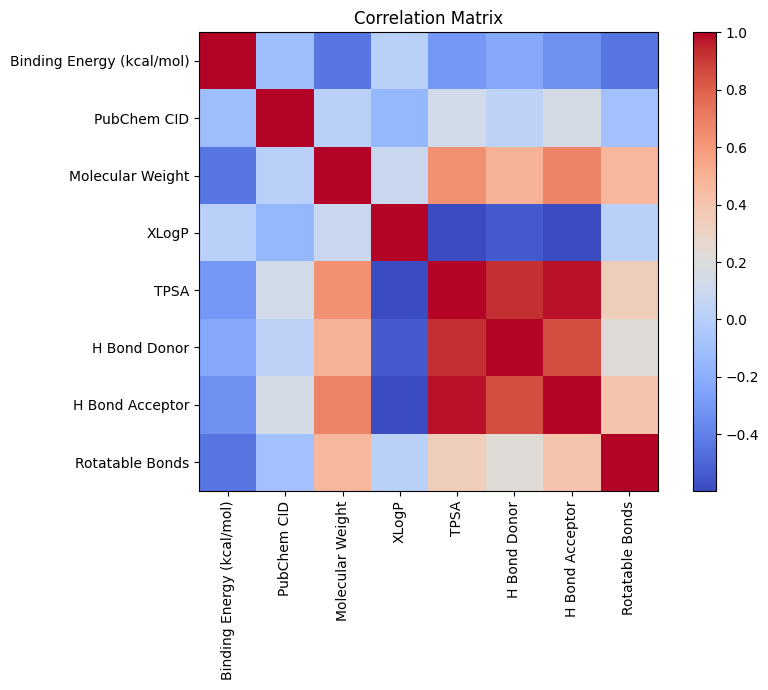

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9,7))

plt.imshow(corr, cmap="coolwarm")

plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(np.arange(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [ ]:
import os

project_path = "/content/drive/MyDrive/Alzheimer_AI_Virtual_Screening"

folders = [
    "Figures",
    "Results",
    "Python",
    "Docking",
    "Protein",
    "Ligands",
    "Literature",
    "Report"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [ ]:
plt.savefig(
    "/content/drive/MyDrive/Alzheimer_AI_Virtual_Screening/Figures/Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Pairwise Scatter Plots

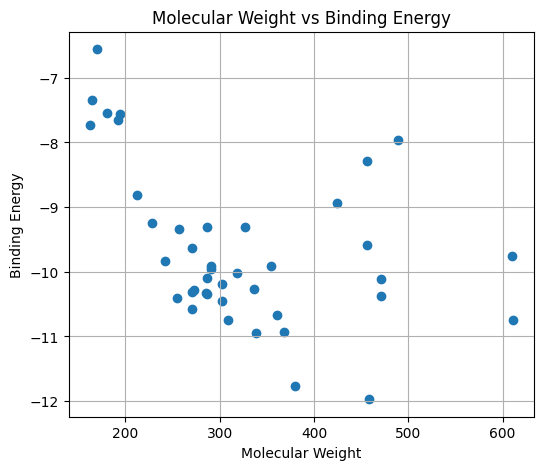

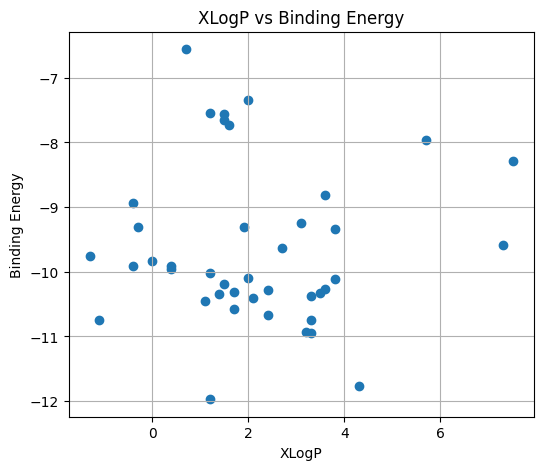

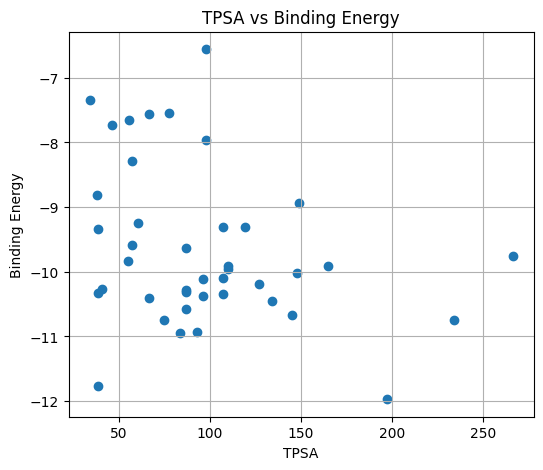

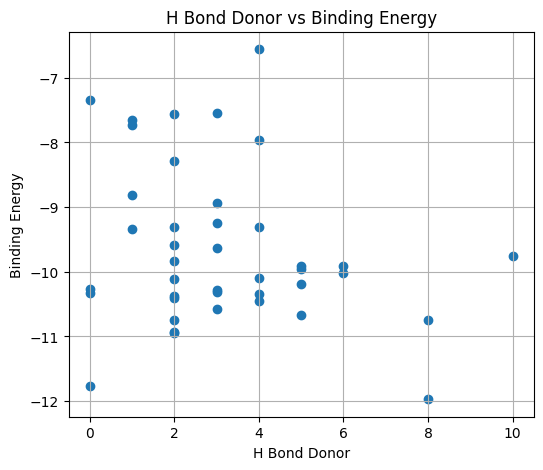

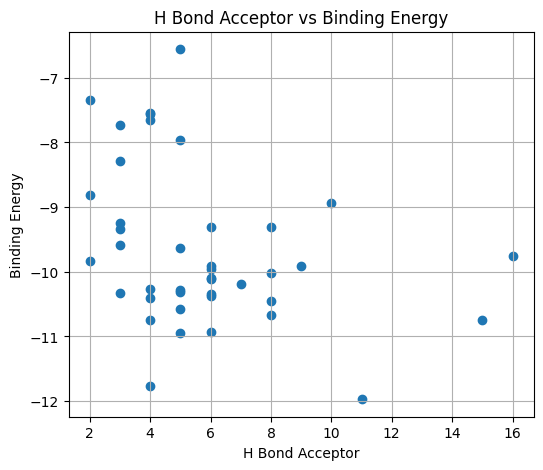

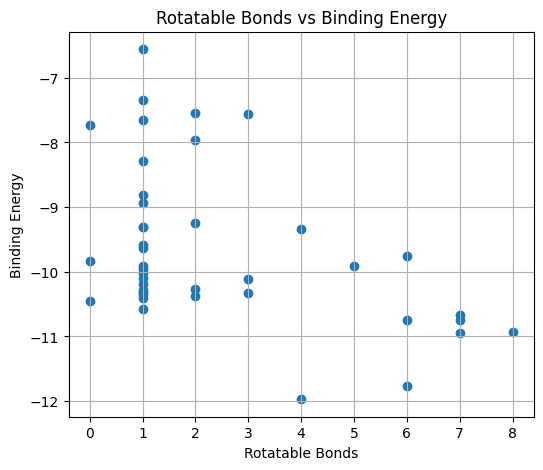

In [ ]:
descriptors = [
    "Molecular Weight",
    "XLogP",
    "TPSA",
    "H Bond Donor",
    "H Bond Acceptor",
    "Rotatable Bonds"
]

for col in descriptors:
    plt.figure(figsize=(6,5))

    plt.scatter(df[col], df["Binding Energy (kcal/mol)"])

    plt.xlabel(col)
    plt.ylabel("Binding Energy")

    plt.title(f"{col} vs Binding Energy")

    plt.grid(True)

    plt.show()

Top 10 Lead Compounds

In [ ]:
top10 = df.nsmallest(10, "Binding Energy (kcal/mol)")

top10

,Ligand,Binding Energy (kcal/mol),PubChem CID,Molecular Weight,XLogP,TPSA,H Bond Donor,H Bond Acceptor,Rotatable Bonds
0,EGCG,-11.972,65064,458.40,1.2,197.0,8,11,4
1,Donepezil,-11.771,3152,379.50,4.3,38.8,0,4,6
2,Demethoxycurcumin,-10.948,5469424,338.40,3.3,83.8,2,5,7
3,Curcumin,-10.932,969516,368.40,3.2,93.1,2,6,8
4,Bisdemethoxycurcumin,-10.749,5315472,308.30,3.3,74.6,2,4,6
5,Hesperidin,-10.739,10621,610.60,-1.1,234.0,8,15,7
6,Rosmarinic acid,-10.675,5281792,360.30,2.4,145.0,5,8,7
7,Baicalein,-10.570,5281605,270.24,1.7,87.0,3,5,1
8,Ellagic acid,-10.447,5281855,302.19,1.1,134.0,4,8,0
9,Chrysin,-10.411,5281607,254.24,2.1,66.8,2,4,1


In [ ]:
top10.to_excel(
    "/content/drive/MyDrive/Alzheimer_AI_Virtual_Screening/Results/Top10_Lead_Compounds.xlsx",
    index=False
)